In [1]:
import pandas as pd
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings 
warnings.filterwarnings('ignore')
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.metrics import accuracy_score

In [2]:

df = pd.read_csv("Pharma_Industry.csv")


In [3]:
df.shape

(500, 6)

In [4]:
df.head()

,Drug Dosage (mg),Systolic Blood Pressure (mmHg),Heart Rate (BPM),Liver Toxicity Index (U/L),Blood Glucose Level (mg/dL),Drug Response
0,-0.128538,0.303280,-1.881849,0.258286,-0.792011,1
1,-1.846188,2.865142,-0.929511,2.866786,-0.719447,1
2,-1.252393,-1.541613,0.363632,-0.325370,0.191314,0
3,1.992515,-1.142779,-0.766657,0.975286,-0.823355,1
4,0.377100,0.538410,-0.029263,1.896015,-0.960130,1


In [5]:
df.isnull().sum()

Drug Dosage (mg)                  0
Systolic Blood Pressure (mmHg)    0
Heart Rate (BPM)                  0
Liver Toxicity Index (U/L)        0
Blood Glucose Level (mg/dL)       0
Drug Response                     0
dtype: int64

In [6]:
df.duplicated().sum()

np.int64(0)

In [7]:
df.columns

Index(['Drug Dosage (mg)', 'Systolic Blood Pressure (mmHg)',
       'Heart Rate (BPM)', 'Liver Toxicity Index (U/L)',
       'Blood Glucose Level (mg/dL)', 'Drug Response'],
      dtype='object')

<Axes: xlabel='Drug Dosage (mg)', ylabel='Systolic Blood Pressure (mmHg)'>

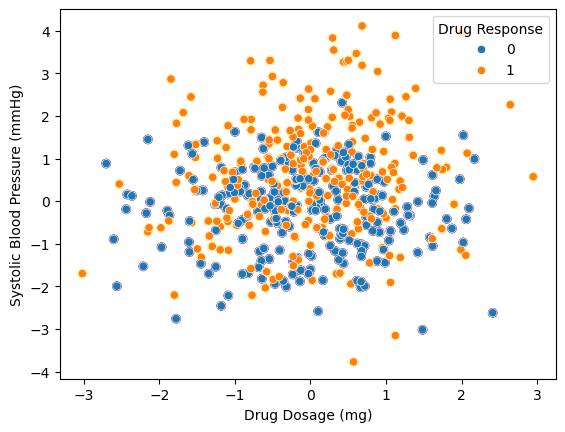

In [8]:
# First scatter plot using plt
plt.scatter(df['Drug Dosage (mg)'], df['Systolic Blood Pressure (mmHg)'], c=df ['Drug Response'])

# Second scatter plot using seaborn
sns.scatterplot(x=df['Drug Dosage (mg)'], y=df['Systolic Blood Pressure (mmHg)'], hue=df['Drug Response'])

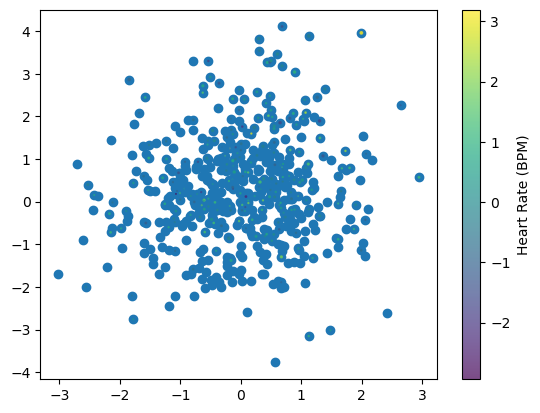

In [9]:
# Option 1: Create a simple scatter plot with just two variables
plt.scatter(df['Drug Dosage (mg)'], df['Systolic Blood Pressure (mmHg)'])

# Option 2: If you want to visualize more dimensions, you can use color and size parameters
plt.scatter(
    df['Drug Dosage (mg)'],                    # x-axis
    df['Systolic Blood Pressure (mmHg)'],      # y-axis
    c=df['Heart Rate (BPM)'],                  # color based on heart rate
    s=df['Liver Toxicity Index (U/L)'],        # size based on liver toxicity
    alpha=0.7                                  # transparency
)

# Add a colorbar to show the heart rate scale
plt.colorbar(label='Heart Rate (BPM)')

# You could also create multiple scatter plots if needed
# plt.figure(figsize=(15, 10))
# plt.subplot(2, 2, 1)
# plt.scatter(df['Drug Dosage (mg)'], df['Systolic Blood Pressure (mmHg)'])
# plt.subplot(2, 2, 2)
# plt.scatter(df['Drug Dosage (mg)'], df['Heart Rate (BPM)'])
# And so on...

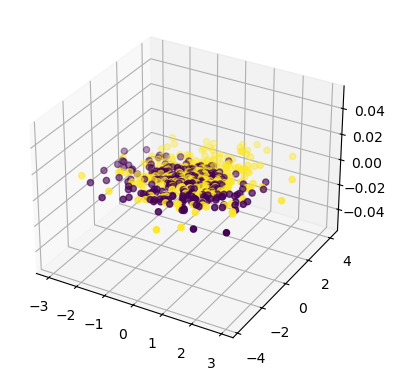

In [10]:
fig=plt.figure(figsize=(10,10))
ax=fig.add_subplot(222,projection='3d')
ax.scatter(df['Drug Dosage (mg)'], df['Systolic Blood Pressure (mmHg)'], c=df['Drug Response'])

In [11]:
target = df[['Drug Response']]
features = df.drop(columns=['Drug Response']) 

In [12]:
## splitting train and test
x_train, x_test, y_train, y_test = train_test_split(features, target, train_size=0.75, random_state=100, stratify=df[['Drug Response']])
print(x_train.shape)
print(x_test.shape)
print(y_train.shape)
print(y_test.shape)

(375, 5)
(125, 5)
(375, 1)
(125, 1)


In [14]:
## model building and validation
from sklearn.svm import SVC  # Import the SVC class from scikit-learn

svc=SVC(C=1,kernel='linear')
svc.fit(x_train,y_train)
y_pred=svc.predict(x_test)
accuracy_score(y_test,y_pred)

0.736

In [15]:
svc=SVC(C=1,kernel='linear')
svc.fit(x_train,y_train)

SVC(C=1, kernel='linear')

In [22]:
x_min=df['Drug Dosage (mg)'].min()-1
x_max=df['Drug Dosage (mg)'].max()+1
y_min=df['Systolic Blood Pressure (mmHg)'].min()-1
y_max=df['Systolic Blood Pressure (mmHg)'].max()+1
print(x_min,x_max,y_min,y_max)

-4.019512155820825 3.949094425308725 -4.773896544445874 5.111750595295886


In [23]:
##step interval
h=0.02

In [28]:
xx,yy=np.meshgrid(np.arange(x_min,x_max,h),np.arange(y_min,y_max,h))

In [29]:
xx

array([[-4.01951216, -3.99951216, -3.97951216, ...,  3.90048784,
         3.92048784,  3.94048784],
       [-4.01951216, -3.99951216, -3.97951216, ...,  3.90048784,
         3.92048784,  3.94048784],
       [-4.01951216, -3.99951216, -3.97951216, ...,  3.90048784,
         3.92048784,  3.94048784],
       ...,
       [-4.01951216, -3.99951216, -3.97951216, ...,  3.90048784,
         3.92048784,  3.94048784],
       [-4.01951216, -3.99951216, -3.97951216, ...,  3.90048784,
         3.92048784,  3.94048784],
       [-4.01951216, -3.99951216, -3.97951216, ...,  3.90048784,
         3.92048784,  3.94048784]])

In [30]:
yy

array([[-4.77389654, -4.77389654, -4.77389654, ..., -4.77389654,
        -4.77389654, -4.77389654],
       [-4.75389654, -4.75389654, -4.75389654, ..., -4.75389654,
        -4.75389654, -4.75389654],
       [-4.73389654, -4.73389654, -4.73389654, ..., -4.73389654,
        -4.73389654, -4.73389654],
       ...,
       [ 5.06610346,  5.06610346,  5.06610346, ...,  5.06610346,
         5.06610346,  5.06610346],
       [ 5.08610346,  5.08610346,  5.08610346, ...,  5.08610346,
         5.08610346,  5.08610346],
       [ 5.10610346,  5.10610346,  5.10610346, ...,  5.10610346,
         5.10610346,  5.10610346]])

In [31]:
xx.shape

(495, 399)

In [33]:
yy.shape

(495, 399)

In [32]:
x_test

,Drug Dosage (mg),Systolic Blood Pressure (mmHg),Heart Rate (BPM),Liver Toxicity Index (U/L),Blood Glucose Level (mg/dL)
69,0.548884,1.151605,-0.254956,0.796077,0.607005
341,-0.197338,-0.857934,-0.151273,2.547218,-0.066550
367,-1.085151,-1.154117,-0.825411,0.402008,0.678181
148,0.105894,1.618744,0.584413,-1.069457,-1.936766
99,0.840620,-0.193123,0.546734,0.480480,-0.254063
...,...,...,...,...,...
11,-0.234020,-1.720723,0.466358,-0.191799,0.451410
283,1.419603,-1.205504,-0.600424,-0.224092,0.059781
216,-0.877983,1.918396,-0.826880,-2.014475,-0.376078
220,1.059936,-1.907993,0.617006,-1.889304,1.871843


In [34]:
x_test.shape

(125, 5)

In [36]:
y_test.shape

(125, 1)

In [39]:
z

array([[-4.01951216, -4.77389654],
       [-3.99951216, -4.77389654],
       [-3.97951216, -4.77389654],
       ...,
       [ 3.90048784,  5.10610346],
       [ 3.92048784,  5.10610346],
       [ 3.94048784,  5.10610346]])

In [41]:
# Option 1: If you need to use the existing model, make sure your input has 5 features
# You'll need to add the missing features to match what the model expects
z = svc.predict(np.c_[np.ravel(xx), np.ravel(yy), np.zeros_like(np.ravel(xx)), np.zeros_like(np.ravel(xx)), np.zeros_like(np.ravel(xx))])

# Option 2: Or retrain your SVC model with 2 features
# svc = SVC(kernel='linear')  # or whatever parameters you were using
# svc.fit(X_train_2d, y_train)  # where X_train_2d has only 2 features
# z = svc.predict(np.c_[np.ravel(xx), np.ravel(yy)])

In [42]:
z

array([0, 0, 0, ..., 1, 1, 1])

In [46]:
z.shape

(197505,)

In [48]:
z1=z.reshape(xx.shape)

In [49]:
z1.shape

(495, 399)

<Axes: xlabel='Drug Dosage (mg)', ylabel='Systolic Blood Pressure (mmHg)'>

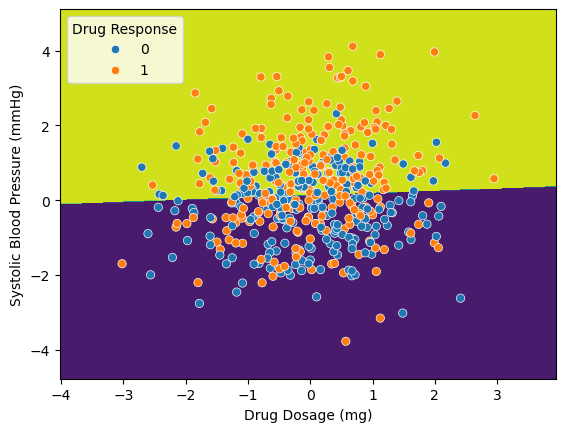

In [51]:
plt.contourf(xx,yy,z1)
sns.scatterplot(x=df['Drug Dosage (mg)'], y=df['Systolic Blood Pressure (mmHg)'], hue=df['Drug Response'])

In [59]:
print(plt.colormaps())

['magma', 'inferno', 'plasma', 'viridis', 'cividis', 'twilight', 'twilight_shifted', 'turbo', 'berlin', 'managua', 'vanimo', 'Blues', 'BrBG', 'BuGn', 'BuPu', 'CMRmap', 'GnBu', 'Greens', 'Greys', 'OrRd', 'Oranges', 'PRGn', 'PiYG', 'PuBu', 'PuBuGn', 'PuOr', 'PuRd', 'Purples', 'RdBu', 'RdGy', 'RdPu', 'RdYlBu', 'RdYlGn', 'Reds', 'Spectral', 'Wistia', 'YlGn', 'YlGnBu', 'YlOrBr', 'YlOrRd', 'afmhot', 'autumn', 'binary', 'bone', 'brg', 'bwr', 'cool', 'coolwarm', 'copper', 'cubehelix', 'flag', 'gist_earth', 'gist_gray', 'gist_heat', 'gist_ncar', 'gist_rainbow', 'gist_stern', 'gist_yarg', 'gnuplot', 'gnuplot2', 'gray', 'hot', 'hsv', 'jet', 'nipy_spectral', 'ocean', 'pink', 'prism', 'rainbow', 'seismic', 'spring', 'summer', 'terrain', 'winter', 'Accent', 'Dark2', 'Paired', 'Pastel1', 'Pastel2', 'Set1', 'Set2', 'Set3', 'tab10', 'tab20', 'tab20b', 'tab20c', 'grey', 'gist_grey', 'gist_yerg', 'Grays', 'magma_r', 'inferno_r', 'plasma_r', 'viridis_r', 'cividis_r', 'twilight_r', 'twilight_shifted_r', 't

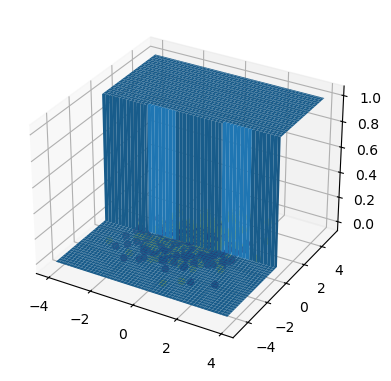

In [55]:
fig=plt.figure(figsize=(10,10))
ax=fig.add_subplot(222,projection='3d')
ax.plot_surface(xx,yy,z1)
ax.scatter(df['Drug Dosage (mg)'], df['Systolic Blood Pressure (mmHg)'], c=df['Drug Response'])

In [57]:
from sklearn.svm import SVC  # Import the SVC class from scikit-learn
## poly model
svc=SVC(C=1,kernel='poly',gamma=0.2)
svc.fit(x_train,y_train)
y_pred=svc.predict(x_test)
accuracy_score(y_test,y_pred)
y_pred

array([1, 1, 1, 0, 1, 1, 1, 1, 1, 1, 0, 1, 0, 1, 0, 1, 0, 0, 0, 0, 0, 1,
       1, 0, 1, 0, 0, 0, 1, 1, 1, 1, 1, 1, 1, 1, 0, 1, 0, 1, 0, 1, 0, 0,
       0, 1, 1, 1, 0, 1, 0, 0, 1, 0, 1, 1, 1, 1, 0, 1, 1, 1, 0, 0, 1, 0,
       0, 1, 0, 0, 0, 1, 0, 0, 0, 1, 1, 1, 0, 0, 0, 1, 0, 1, 0, 0, 0, 1,
       0, 1, 1, 1, 0, 1, 0, 0, 0, 1, 1, 1, 1, 0, 1, 0, 0, 0, 0, 0, 0, 1,
       1, 0, 0, 0, 1, 1, 1, 0, 0, 1, 0, 0, 0, 1, 0])

In [58]:
z = svc.predict(np.c_[np.ravel(xx), np.ravel(yy), np.zeros_like(np.ravel(xx)), np.zeros_like(np.ravel(xx)), np.zeros_like(np.ravel(xx))])

In [60]:
z1=z.reshape(xx.shape)

<Axes: xlabel='Drug Dosage (mg)', ylabel='Systolic Blood Pressure (mmHg)'>

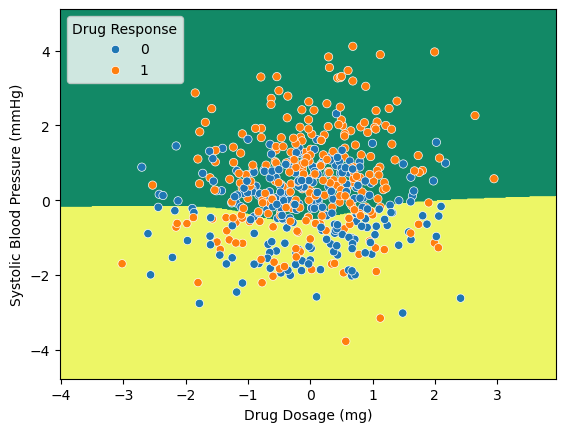

In [62]:
plt.contourf(xx,yy,z1,cmap='summer_r')
sns.scatterplot(x=df['Drug Dosage (mg)'], y=df['Systolic Blood Pressure (mmHg)'], hue=df['Drug Response'])

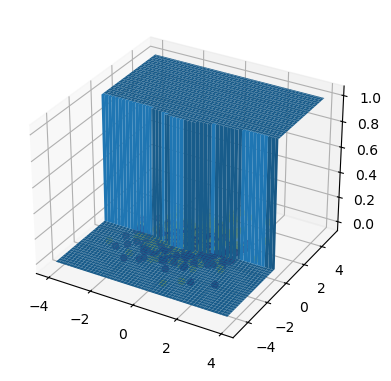

In [63]:
fig=plt.figure(figsize=(10,10))
ax=fig.add_subplot(222,projection='3d')
ax.plot_surface(xx,yy,z1)
ax.scatter(df['Drug Dosage (mg)'], df['Systolic Blood Pressure (mmHg)'], c=df['Drug Response'])

In [64]:
from sklearn.svm import SVC  # Import the SVC class from scikit-learn
## rbf model
svc=SVC(C=1,kernel='rbf',gamma=0.2)
svc.fit(x_train,y_train)
y_pred=svc.predict(x_test)
accuracy_score(y_test,y_pred)


0.792

In [65]:
z = svc.predict(np.c_[np.ravel(xx), np.ravel(yy), np.zeros_like(np.ravel(xx)), np.zeros_like(np.ravel(xx)), np.zeros_like(np.ravel(xx))])

In [66]:
z1=z.reshape(xx.shape)

<Axes: xlabel='Drug Dosage (mg)', ylabel='Systolic Blood Pressure (mmHg)'>

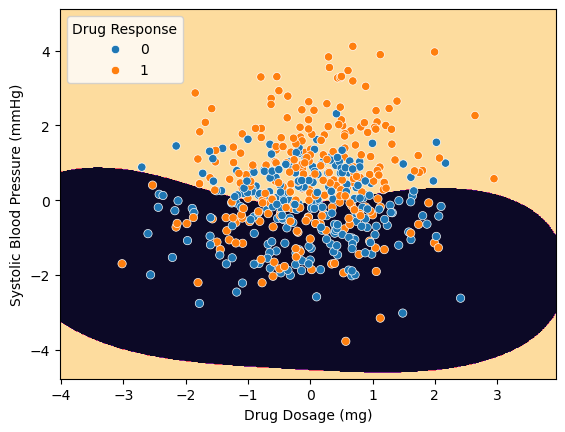

In [69]:
plt.contourf(xx,yy,z1,cmap='magma')
sns.scatterplot(x=df['Drug Dosage (mg)'], y=df['Systolic Blood Pressure (mmHg)'], hue=df['Drug Response'])

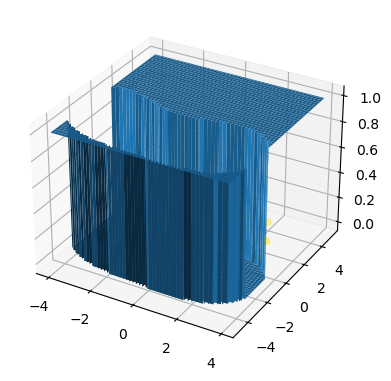

In [70]:
fig=plt.figure(figsize=(10,10))
ax=fig.add_subplot(222,projection='3d')
ax.plot_surface(xx,yy,z1)
ax.scatter(df['Drug Dosage (mg)'], df['Systolic Blood Pressure (mmHg)'], c=df['Drug Response'])

In [72]:
from sklearn.svm import SVC  # Import the SVC class from scikit-learn
## sigmoid model
svc=SVC(C=1,kernel='sigmoid',gamma=0.2)
svc.fit(x_train,y_train)
y_pred=svc.predict(x_test)
accuracy_score(y_test,y_pred)


0.608

In [73]:
z = svc.predict(np.c_[np.ravel(xx), np.ravel(yy), np.zeros_like(np.ravel(xx)), np.zeros_like(np.ravel(xx)), np.zeros_like(np.ravel(xx))])

In [74]:
z1=z.reshape(xx.shape)

<Axes: xlabel='Drug Dosage (mg)', ylabel='Systolic Blood Pressure (mmHg)'>

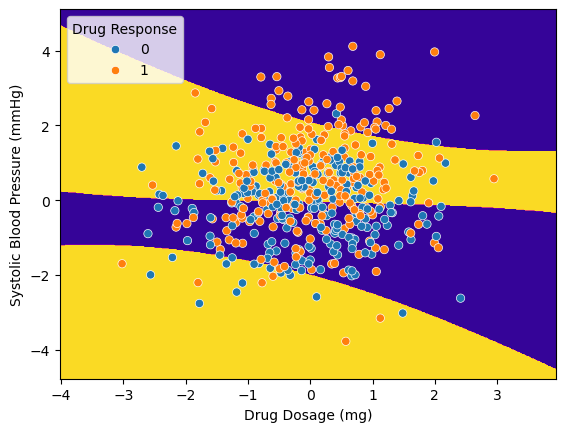

In [77]:
plt.contourf(xx,yy,z1,cmap='plasma')

sns.scatterplot(x=df['Drug Dosage (mg)'], y=df['Systolic Blood Pressure (mmHg)'], hue=df['Drug Response'])

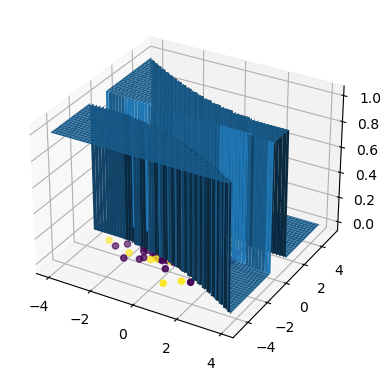

In [78]:
fig=plt.figure(figsize=(10,10))
ax=fig.add_subplot(222,projection='3d')
ax.plot_surface(xx,yy,z1)
ax.scatter(df['Drug Dosage (mg)'], df['Systolic Blood Pressure (mmHg)'], c=df['Drug Response'])

##  Comparison of SVM Performance with Different Kernels
Support Vector Machine (SVM) performance varies depending on the kernel used:
###  Linear Kernel
Works well when the data is linearly separable.
Faster training time.
Performs well on high-dimensional datasets.
May underperform if the data has complex non-linear patterns.

##### Polynomial Kernel
Captures non-linear relationships.
Performance depends on the degree parameter.
Higher degree may lead to overfitting.
Slower than linear kernel.

### RBF (Radial Basis Function) Kernel
Handles complex non-linear boundaries effectively.
Usually gives better accuracy for non-linear datasets.
Requires tuning of hyperparameters (C and gamma).
Slightly higher computational cost.

Conclusion:

If the dataset shows linear separation (from visualization), the linear kernel performs well.
If the dataset shows non-linear patterns, RBF typically provides the best accuracy.

# 2. Strengths and Weaknesses of SVM (Based on EDA & Visualization)
###Strengths
Effective in high-dimensional spaces.
Works well when classes are clearly separated.
Robust to overfitting when margin is properly maximized.
Kernel trick allows handling non-linear data.

## Weaknesses
Sensitive to parameter tuning (C, gamma).
Slower for large datasets.
Not easily interpretable.
Performance decreases with noisy or overlapping classes.

## From EDA:
If features show clear clusters → SVM performs well.
If classes overlap heavily → Accuracy may reduce.


